# Figure5_3

In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

from functions.load_data import loadTrialsM
from functions.utils import index_in, first_trials_by_image
from functions.decoding import load_feature_mat, image_basenames, fit_logistic
from functions.plotting import set_paper_theme

set_paper_theme()


In [2]:

# Analysis parameters
# Recording areas to run the ceiling analysis on ('V1' is the lowercase file suffix).
MODELS = ['IT', 'V1', 'V4']
MODEL_INFO = {
    'IT': {'label': 'IT', 'color': 'black'},
    'V1': {'label': 'V1', 'color': '#D62728'},
    'V4': {'label': 'V4', 'color': '#1F77B4'},
}
N_REPEATS = 10
N_FOLDS = 5
N_PCA_COMPONENTS = 20
RANDOM_SEED = 42

# Hand-picked neuron counts: spans ~3 orders of magnitude with denser sampling
# at the low end so the steep early-rise regime is captured. Counts below
# N_PCA_COMPONENTS are capped automatically (n_pca_eff = n_neurons there).
NEURON_COUNTS = [1, 2, 5, 10, 20, 50, 100, 200]

OUTPUT_DIR = 'results/Figure5'   # figure PDFs and per-(area, task) result CSVs

TASK_CONFIG = [
    {
        'task_name': 'Large_animate_vs_inanimate',
        'feature_name': 'Large_animate_vs_inanimate',
        'color': 'black',
        'label': 'Animate vs. Inanimate',
    },
    {
        'task_name': 'Large_mammal_vs_nonmammal',
        'feature_name': 'Large_mammal_vs_nonmammal',
        'color': '#5EA66B',
        'label': 'Mammal vs. Non-mammal',
    },
    {
        'task_name': 'Large_natural_vs_artificial',
        'feature_name': 'Large_natural_vs_artificial',
        'color': '#8074B1',
        'label': 'Natural vs. Artificial',
    },
]


In [ ]:

def load_behavior_data(task):
    """Load monkey behavioral data for a given task.

    Returns gen-set labels/accuracy plus the unique anchor (main) images and
    their category labels, the latter being needed for the train-on-main
    (non-CV) analysis.
    """
    trials_main, trials_gen = [], []
    for monkey in ['Elsa', 'Judy', 'Olaf']:
        _trials, _ = loadTrialsM(task, monkey)
        # exclude the swipe-format anchor-image practice session
        _trials_main = [trial for trial in _trials if trial['trial_type'] == 'main']
        _trials_gen, _ = first_trials_by_image([trial for trial in _trials if trial['trial_type'] == 'gen'])
        trials_main.extend(_trials_main)
        trials_gen.extend(_trials_gen)

    gen_acc = np.mean([trial['result'] == 'CORRECT' for trial in trials_gen])

    images_gen = np.array([trial['img_url'].split('/')[-1] for trial in trials_gen])

    # target2 is defined from the anchor choices (two categories), consistent with Figure4
    _choices_main = np.array([trial['targ_cat'][trial['response'] - 1] for trial in trials_main])
    _category_gen = np.array([trial['targ_cat'][trial['targ_cor'] - 1] for trial in trials_gen])

    target2 = np.sort(list(set(_choices_main)))[1]
    category_gen = (_category_gen == target2) + 1

    # Unique anchor (main) images and their category labels. The anchor's
    # category is the category of the correct target on that trial.
    trials_main_u, _ = first_trials_by_image(trials_main)
    images_main = np.array([trial['img_url'].split('/')[-1] for trial in trials_main_u])
    _category_main = np.array([trial['targ_cat'][trial['targ_cor'] - 1] for trial in trials_main_u])
    category_main = (_category_main == target2) + 1

    return gen_acc, images_gen, category_gen, images_main, category_main


def load_area_features(feature_name, model_name, images_gen, images_main):
    """Load neural features for an area (e.g. IT/V1/V4) and align with gen and anchor (main) images."""
    X, _, fnames = load_feature_mat(f'data_model/largetask_features/{feature_name}_{model_name}.mat')
    trial_type = np.array([name.split('\\')[2] for name in fnames])
    names = image_basenames(fnames)

    names_gen = names[trial_type == 'stim']
    X_gen = X[trial_type == 'stim']
    XX_gen = X_gen[index_in(images_gen, names_gen)]

    names_main = names[trial_type == 'anchor']
    X_main = X[trial_type == 'anchor']
    XX_main = X_main[index_in(images_main, names_main)]

    return XX_gen, XX_main


def style_log_xaxis(ax, n_arr, max_ticks=6, rotation=0):
    """Apply a clean log x-axis with at most ``max_ticks`` labeled ticks.

    The data points themselves remain visible (markers on the curve); only
    the *tick labels* are thinned out so they don't overlap.
    """
    ax.set_xscale('log')
    ax.set_xticks(n_arr)
    ax.minorticks_off()

    n = len(n_arr)
    if n > max_ticks:
        step = int(np.ceil(n / max_ticks))
        show = np.zeros(n, dtype=bool)
        show[::step] = True
        # Always include the first and last so the axis range is unambiguous.
        show[0] = True
        show[-1] = True
    else:
        show = np.ones(n, dtype=bool)
    labels = [str(int(v)) if flag else '' for v, flag in zip(n_arr, show)]
    ax.set_xticklabels(labels, rotation=rotation, ha='center' if rotation == 0 else 'right')
    ax.set_xlim(n_arr.min() * 0.85, n_arr.max() / 0.85)


def _fit_predict(X_train, y_train, X_test, n_pca_eff):
    """PCA -> StandardScaler -> logistic classifier, return test predictions."""
    pca = PCA(n_components=n_pca_eff, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    ss = StandardScaler()
    X_train_pca = ss.fit_transform(X_train_pca)
    X_test_pca = ss.transform(X_test_pca)

    return fit_logistic(X_train_pca, y_train).predict(X_test_pca)


def run_ceiling_analysis(task_name, feature_name, model_name):
    """Run the neuron-ceiling analysis for one area and task.

    Two decoder evaluations are computed on the *same* neuron subsamples:
      - CV:     5-fold cross-validation within the gen images (PCA20).
      - non-CV: train on the anchor (main) images, test on the gen images.
    """
    monkey_performance, images_gen, category_gen, images_main, category_main = load_behavior_data(task_name)
    print(f'\n--- {task_name} ---')
    print(f'Monkey generalization accuracy: {monkey_performance:.3f}')
    print(f'Number of gen images: {len(images_gen)}')
    print(f'Number of unique main (anchor) images: {len(images_main)}')

    XX_gen_raw, XX_main_raw = load_area_features(feature_name, model_name, images_gen, images_main)
    n_neurons_total = XX_gen_raw.shape[1]
    print(f'Total {model_name} neurons available: {n_neurons_total}')
    print(f'Feature matrix shape (gen): {XX_gen_raw.shape}, (main): {XX_main_raw.shape}')

    # Hand-picked neuron counts, filtered to be <= n_neurons_total.
    neuron_counts = list(NEURON_COUNTS)
    if neuron_counts[-1] != n_neurons_total:
        neuron_counts.append(n_neurons_total)
    print(f'Neuron counts to test: {neuron_counts}')

    results = {
        'model': [],
        'n_neurons': [],
        'CV_mean': [],
        'CV_SE': [],
        'nonCV_mean': [],
        'nonCV_SE': [],
        'monkey_performance': [],
        'label': [],
        'color': [],
    }

    np.random.seed(RANDOM_SEED)

    for n_neurons in neuron_counts:
        CV_all, nonCV_all = [], []

        for rep in range(N_REPEATS):
            if n_neurons == n_neurons_total:
                selected_idx = np.arange(n_neurons_total)
            else:
                selected_idx = np.random.choice(n_neurons_total, size=n_neurons, replace=False)

            XX_gen = XX_gen_raw[:, selected_idx]
            XX_main = XX_main_raw[:, selected_idx]

            # Cap PCA components to the subsample size (and to the number of
            # main images for the non-CV fit) so sklearn does not raise.
            n_pca_eff = min(N_PCA_COMPONENTS, n_neurons, XX_main.shape[0])

            # --- 5-fold CV within the gen images ---
            kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED + rep)
            fold_scores = []
            for train_idx, test_idx in kfold.split(XX_gen, category_gen):
                pred = _fit_predict(XX_gen[train_idx], category_gen[train_idx],
                                    XX_gen[test_idx], n_pca_eff)
                fold_scores.append(np.mean(pred == category_gen[test_idx]))
            CV_all.append(np.mean(fold_scores))

            # --- train on main (anchor) images, test on gen images ---
            pred = _fit_predict(XX_main, category_main, XX_gen, n_pca_eff)
            nonCV_all.append(np.mean(pred == category_gen))

        results['model'].append(model_name)
        results['n_neurons'].append(n_neurons)
        results['CV_mean'].append(np.mean(CV_all))
        results['CV_SE'].append(np.std(CV_all) / np.sqrt(N_REPEATS))
        results['nonCV_mean'].append(np.mean(nonCV_all))
        results['nonCV_SE'].append(np.std(nonCV_all) / np.sqrt(N_REPEATS))
        results['monkey_performance'].append(monkey_performance)
        results['label'].append('')
        results['color'].append('')

        print(f'Neurons: {n_neurons:4d} | '
              f'CV: {np.mean(CV_all):.3f} +/- {np.std(CV_all) / np.sqrt(N_REPEATS):.3f} | '
              f'train-main: {np.mean(nonCV_all):.3f} +/- {np.std(nonCV_all) / np.sqrt(N_REPEATS):.3f}')

    return results, monkey_performance, neuron_counts


In [4]:

os.makedirs(OUTPUT_DIR, exist_ok=True)

for model_name in MODELS:
    for config in TASK_CONFIG:
        task_name = config['task_name']
        feature_name = config['feature_name']
        color = config['color']
        task_label = config['label']

        # Cache: each per-(area, task) CSV holds the full numeric results and
        # the plotting half below reads the CSVs from disk. When a CSV exists,
        # skip the (slow) decoding and reuse it; delete the CSVs to recompute.
        csv_name = f'{model_name}_ceiling_{task_name}_CV_vs_trainMain_PCA20.csv'
        csv_path = os.path.join(OUTPUT_DIR, csv_name)
        if os.path.exists(csv_path):
            print(f'[cache] {csv_name} exists, skipping decoding')
            continue

        results, monkey_performance, _ = run_ceiling_analysis(task_name, feature_name, model_name)

        # Save CSV (with metadata columns for later plotting).
        df = pd.DataFrame(results)
        df['label'] = task_label
        df['color'] = color
        df['monkey_performance'] = monkey_performance
        df.to_csv(csv_path, index=False)
        print(df[['n_neurons', 'CV_mean', 'CV_SE', 'nonCV_mean', 'nonCV_SE']])
        print(f'Saved results to {csv_path}\n')



--- Large_animate_vs_inanimate ---
Monkey generalization accuracy: 0.888
Number of gen images: 10749
Number of unique main (anchor) images: 100
Total IT neurons available: 576
Feature matrix shape (gen): (10749, 576), (main): (100, 576)
Neuron counts to test: [1, 2, 5, 10, 20, 50, 100, 200, 576]
Neurons:    1 | CV: 0.585 +/- 0.015 | train-main: 0.558 +/- 0.020
Neurons:    2 | CV: 0.635 +/- 0.022 | train-main: 0.612 +/- 0.027
Neurons:    5 | CV: 0.718 +/- 0.017 | train-main: 0.686 +/- 0.019
Neurons:   10 | CV: 0.756 +/- 0.017 | train-main: 0.708 +/- 0.020
Neurons:   20 | CV: 0.832 +/- 0.009 | train-main: 0.759 +/- 0.010
Neurons:   50 | CV: 0.864 +/- 0.004 | train-main: 0.790 +/- 0.005
Neurons:  100 | CV: 0.883 +/- 0.003 | train-main: 0.811 +/- 0.005
Neurons:  200 | CV: 0.894 +/- 0.002 | train-main: 0.819 +/- 0.003
Neurons:  576 | CV: 0.905 +/- 0.000 | train-main: 0.831 +/- 0.000
   n_neurons   CV_mean     CV_SE  nonCV_mean      nonCV_SE
0          1  0.585226  0.014874    0.557996  2.0

---
## Plotting from saved CSVs

In [5]:

PLOT_CONFIG = {
    'figwidth': 90 / 75,        # inches
    'figheight': 60 / 75,       # inches
    'dpi': 300,
    'markersize': 2,
    'linewidth': 1.0,
    'monkey_linecolor': '#E76A00',
    'monkey_linestyle': '--',
    'chance_linecolor': 'black',
    'chance_linestyle': ':',
    'ylim': [0.4, 1.0],
    'yticks': [0.4, 0.6, 0.8, 1.0],
    'xtick_major': [1, 10, 100, 1000],  # clean log major ticks instead of every data point
    'output_dir': OUTPUT_DIR,
}

# Per-area style: each area gets a distinct MARKER. COLOR is per-task (taken
# from the CSV 'color' column / TASK_INFO), so all three curves in one panel
# share the task color and are told apart by marker shape.
AREA_INFO = {
    'IT': {'label': 'IT', 'marker': 'o'},   # circle
    'V1': {'label': 'V1', 'marker': 's'},   # square
    'V4': {'label': 'V4', 'marker': '^'},   # triangle
}

# Fallback metadata for CSVs that were saved without the extra columns.
TASK_INFO = {
    'Large_animate_vs_inanimate': {
        'label': 'Animate vs. Inanimate',
        'color': 'black',
        'monkey_performance': 0.888455,
    },
    'Large_mammal_vs_nonmammal': {
        'label': 'Mammal vs. Non-mammal',
        'color': '#5EA66B',
        'monkey_performance': 0.819303,
    },
    'Large_natural_vs_artificial': {
        'label': 'Natural vs. Artificial',
        'color': '#8074B1',
        'monkey_performance': 0.866116,
    },
}

csv_pattern = os.path.join(OUTPUT_DIR, '*_ceiling_Large_*_CV_vs_trainMain_PCA20.csv')
csv_files = sorted(glob.glob(csv_pattern))
print('Found CSV files:')
for f in csv_files:
    print(' ', f)


Found CSV files:
  results/Figure5\IT_ceiling_Large_animate_vs_inanimate_CV_vs_trainMain_PCA20.csv
  results/Figure5\IT_ceiling_Large_mammal_vs_nonmammal_CV_vs_trainMain_PCA20.csv
  results/Figure5\IT_ceiling_Large_natural_vs_artificial_CV_vs_trainMain_PCA20.csv
  results/Figure5\V1_ceiling_Large_animate_vs_inanimate_CV_vs_trainMain_PCA20.csv
  results/Figure5\V1_ceiling_Large_mammal_vs_nonmammal_CV_vs_trainMain_PCA20.csv
  results/Figure5\V1_ceiling_Large_natural_vs_artificial_CV_vs_trainMain_PCA20.csv
  results/Figure5\V4_ceiling_Large_animate_vs_inanimate_CV_vs_trainMain_PCA20.csv
  results/Figure5\V4_ceiling_Large_mammal_vs_nonmammal_CV_vs_trainMain_PCA20.csv
  results/Figure5\V4_ceiling_Large_natural_vs_artificial_CV_vs_trainMain_PCA20.csv


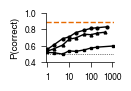

Saved figure to results/Figure5\neural_decoding_Large_animate_vs_inanimate_trainMain.pdf


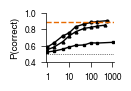

Saved figure to results/Figure5\neural_decoding_Large_animate_vs_inanimate_5foldCV.pdf


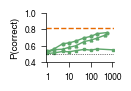

Saved figure to results/Figure5\neural_decoding_Large_mammal_vs_nonmammal_trainMain.pdf


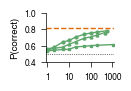

Saved figure to results/Figure5\neural_decoding_Large_mammal_vs_nonmammal_5foldCV.pdf


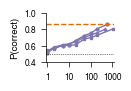

Saved figure to results/Figure5\neural_decoding_Large_natural_vs_artificial_trainMain.pdf


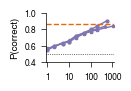

Saved figure to results/Figure5\neural_decoding_Large_natural_vs_artificial_5foldCV.pdf


In [6]:
def plot_from_csv(dfs, task_label, version='CV', save_path=None, cfg=None, area_info=None):
    """Plot an area-ceiling figure from saved results DataFrames.

    One curve per area (IT/V1/V4) is drawn from each DataFrame in ``dfs``.
    Color encodes the TASK (shared by all three curves); areas are told apart
    by marker shape. There is no in-axes legend and no x-axis label — a
    standalone area legend is produced separately.
    The CV and non-CV versions differ only in the data column drawn
    ('CV_mean' vs 'nonCV_mean'). The per-repeat SEM is stored in the CSVs but
    not drawn.
    """
    if cfg is None:
        cfg = PLOT_CONFIG
    if area_info is None:
        area_info = AREA_INFO

    if version == 'nonCV':
        mean_col = 'nonCV_mean'
    else:
        mean_col = 'CV_mean'

    # Color encodes the task; the CSV carries the task color.
    task_color = dfs[0]['color'].iloc[0] if 'color' in dfs[0].columns else 'black'

    # constrained_layout (the rcParam default) keeps the panel at the original
    # IT-only figure size. NOTE: it breaks with an OUTSIDE legend
    # (bbox_to_anchor -> axes collapse to a strip); this figure has no legend
    # so it is safe. If you re-add an outside legend, switch to layout='none'.
    fig, ax = plt.subplots(1, 1, layout='constrained')
    fig.set(figwidth=cfg['figwidth'], figheight=cfg['figheight'])

    for df in dfs:
        model = str(df['model'].iloc[0]) if 'model' in df.columns else None
        info = area_info.get(model, {}) if model is not None else {}
        marker = info.get('marker', 'o')

        n_arr = df['n_neurons'].values
        ax.plot(
            n_arr, df[mean_col].values,
            marker=marker, color=task_color,
            markerfacecolor=task_color, markeredgecolor=task_color,
            markersize=cfg['markersize'], linewidth=cfg['linewidth'],
        )

    # Monkey performance is a property of the task, identical across curves.
    monkey_performance = (dfs[0]['monkey_performance'].iloc[0]
                          if 'monkey_performance' in dfs[0].columns else 0.5)
    ax.axhline(monkey_performance, color=cfg['monkey_linecolor'],
               linestyle=cfg['monkey_linestyle'], linewidth=1)
    ax.axhline(0.5, color=cfg['chance_linecolor'], linestyle=cfg['chance_linestyle'], linewidth=0.5)

    # Log x-axis with clean major ticks (1/10/100/1000). Limits cover all areas
    # (IT 576 / v1 1024 / V4 448), so each curve ends at its own neuron count.
    major = np.array(cfg.get('xtick_major', []), dtype=float)
    if len(major):
        style_log_xaxis(ax, major, max_ticks=len(major))
    else:
        n_union = np.unique(np.concatenate([df['n_neurons'].values for df in dfs]))
        style_log_xaxis(ax, n_union, max_ticks=cfg.get('max_xticks', 6))
    ax.set_yticks(cfg['yticks'])
    ax.set_ylabel('P(correct)')
    ax.set_ylim(cfg['ylim'])

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=cfg['dpi'], bbox_inches='tight', transparent=True)
        plt.show()
        print(f'Saved figure to {save_path}')
    return fig, ax


# Figure versions to produce per task: 'CV' (5-fold CV only) or
# 'nonCV' (train-on-main only). Each version gets its own figure file.
VERSIONS_TO_PLOT = ['nonCV', 'CV']
VERSION_FILE_TAG = {
    'CV':    '5foldCV',
    'nonCV': 'trainMain',
}

# Group saved CSVs by task, then plot all areas into one figure per (task, version).
tasks = {}
for csv_path in csv_files:
    basename = os.path.basename(csv_path)
    stem = basename.replace('_CV_vs_trainMain_PCA20.csv', '')
    model, task_key = stem.split('_ceiling_', 1)
    tasks.setdefault(task_key, []).append((model, csv_path))

# Plot every task.  Adjust PLOT_CONFIG / AREA_INFO / TASK_INFO above or
# override per-task below.
area_order = {m: i for i, m in enumerate(MODELS)}
for task_key, entries in sorted(tasks.items()):
    entries.sort(key=lambda x: area_order.get(x[0], len(area_order)))
    dfs = [pd.read_csv(csv_path) for _, csv_path in entries]

    fallback = TASK_INFO.get(task_key, {})
    task_label = dfs[0]['label'].iloc[0] if 'label' in dfs[0].columns else fallback.get('label', task_key)

    for version in VERSIONS_TO_PLOT:
        fig_name = f'neural_decoding_{task_key}_{VERSION_FILE_TAG[version]}.pdf'
        save_path = os.path.join(PLOT_CONFIG['output_dir'], fig_name)
        plot_from_csv(dfs, task_label, version=version, save_path=save_path)
        plt.show()

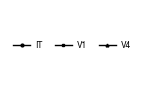

Saved area legend to results/Figure5\neural_area_legend.pdf


In [7]:
def plot_area_legend(save_path, cfg=None, area_info=None):
    """Standalone area legend (one marker per area).

    Entries are drawn side by side in a single row. Markers are drawn in black
    so the legend can be re-colored by hand to match each task's color in the
    final figure.
    """
    if cfg is None:
        cfg = PLOT_CONFIG
    if area_info is None:
        area_info = AREA_INFO

    fig, ax = plt.subplots(1, 1, layout='none')
    fig.set(figwidth=cfg['figwidth'], figheight=cfg['figheight'])
    for m in MODELS:
        info = area_info[m]
        ax.plot([], [], marker=info.get('marker', 'o'), linestyle='-',
                color='black', markerfacecolor='black', markeredgecolor='black',
                markersize=cfg['markersize'], linewidth=cfg['linewidth'],
                label=info['label'])
    ax.legend(loc='center', frameon=False, handletextpad=0.6, labelspacing=0.8,
              ncols=len(MODELS), columnspacing=1.5)
    ax.axis('off')

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=cfg['dpi'], bbox_inches='tight', transparent=True)
    plt.show()
    print(f'Saved area legend to {save_path}')
    return fig


plot_area_legend(os.path.join(PLOT_CONFIG['output_dir'], 'neural_area_legend.pdf'))
plt.show()